# imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

In [23]:
X = np.array([
	[170, 25, 1],
	[180, 30, 1],
	[200, 35, 1]
])

y = np.array([
	[7], 
	[8], 
	[12]
])

In [24]:
theta = np.linalg.pinv(X) @ y
theta

array([[  0.3],
       [ -0.4],
       [-34. ]])

In [17]:
# theta = np.array([[-0.06],
#        [ 0.6181146 ]])

In [25]:
y_pred = X@theta
y_pred

array([[ 7.],
       [ 8.],
       [12.]])

In [26]:
np.abs(y - y_pred).mean()

np.float64(2.842170943040401e-14)

In [28]:
X_test = np.array([
	[175, 40, 1],
])

X_test @ theta

array([[2.5]])

In [34]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X[:, :2], y)
lr.predict(np.array([
	[175, 40],
]))

array([[2.5]])

In [32]:
lr.coef_, lr.intercept_

(array([[ 0.3, -0.4]]), array([-34.]))

In [33]:
theta

array([[  0.3],
       [ -0.4],
       [-34. ]])

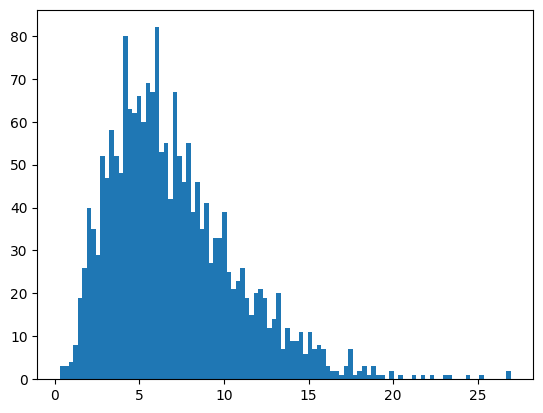

In [97]:
m = 2000

boylar = np.random.normal(loc=170, scale=10, size=(m,1))
yashlar = np.random.uniform(low=18, high=60, size=(m,1))
maashlar = np.random.gamma(shape=3.5, scale = 2.0, size=(m,1))

plt.hist(maashlar, bins=100);

In [108]:
np.ones(5)

array([1., 1., 1., 1., 1.])

In [116]:
from sklearn.preprocessing import add_dummy_feature
# X = np.concat([boylar, yashlar, np.ones(shape=(m,1))], axis=1)
X = np.concat([boylar, yashlar], axis=1)
X_b = add_dummy_feature(X, value=1)
y = maashlar.copy()

theta = np.linalg.pinv(X_b) @ y
theta

array([[5.80740064e+00],
       [7.25848748e-03],
       [4.12460015e-05]])

In [117]:
X_test = np.array([
	[1, 175, 40],
])
X_test @ theta 

array([[7.07928579]])

In [149]:
from sklearn.impute import SimpleImputer

csv_path = Path(r"C:\Users\user\Desktop\div\data\files\housing.csv")
df = pd.read_csv(csv_path)
X = df.iloc[:, :-2].to_numpy()
y = df.iloc[:, [-2]].to_numpy()

X.shape

(20640, 8)

In [150]:
simp_imp = SimpleImputer()
X = simp_imp.fit_transform(X)

X_b = add_dummy_feature(X)


theta = np.linalg.pinv(X_b) @ y
theta

array([[-3.57149155e+06],
       [-4.26216988e+04],
       [-4.24794502e+04],
       [ 1.14447861e+03],
       [-6.68056553e+00],
       [ 8.24636108e+01],
       [-3.98332646e+01],
       [ 7.81123472e+01],
       [ 3.97716181e+04]])

In [153]:
X_test = X_b[[1], :] 
X_test @ theta

array([[420686.2639695]])